In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Analysis

In [58]:
df=pd.read_csv('zomato_reviews.csv')
df.head()

,review_id,rating,review_text,review_date,helpful
0,90749778-cd88-4c19-8b12-1fce7e7d82f8,4,kindly requesting to return change . we are fo...,2025-11-27 08:15:26,0
1,aa848bb6-d242-4a7e-831e-4f21e2e60c6e,1,"Hiked prices, packing and platform charges",2025-11-27 08:08:31,0
2,4f888388-9f28-44a4-8601-491a87035e53,5,good discount,2025-11-27 04:20:28,0
3,490a16b3-aacf-4204-bdcb-ffdbf04add72,1,"Zomato in its initial days was too good, but c...",2025-11-27 03:34:38,0
4,0090a503-13b8-4741-a7c0-42e811244563,5,good application,2025-11-27 02:50:58,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    20000 non-null  object
 1   rating       20000 non-null  int64 
 2   review_text  20000 non-null  object
 3   review_date  20000 non-null  object
 4   helpful      20000 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 781.4+ KB


In [60]:
df.columns

Index(['review_id', 'rating', 'review_text', 'review_date', 'helpful'], dtype='object')

# Data Cleaning

In [61]:
df.duplicated().sum()

0

In [62]:
df.isnull().sum()

review_id      0
rating         0
review_text    0
review_date    0
helpful        0
dtype: int64

In [63]:
df['helpful'].unique()

array([  0,   9,   5,   1,  22,   2,   3,  64,  11,   4,  65,  67,  21,
        94,  12,  13,  80,  68, 272,  69,   6, 131,  34,  60,  27,   8,
        49,   7, 120,  39,  43, 135, 214, 551,  23,  10, 357,  19, 199,
       228, 197,  20,  66,  18,  35,  45,  14, 125, 123, 128,  92, 477,
       158, 104,  98,  44,  72,  37, 133, 176,  25, 256, 137,  70, 118,
       154, 265,  16,  29,  48, 105,  17, 419, 288, 109, 175, 374,  40,
       188, 253, 548,  93, 100, 342,  33, 320, 708, 134, 279,  85, 139,
        15, 310, 149, 138, 148, 247,  51,  38,  24,  42,  73,  26],
      dtype=int64)

In [64]:
df['review_date'] = pd.to_datetime(df['review_date'])

# Future Engineering

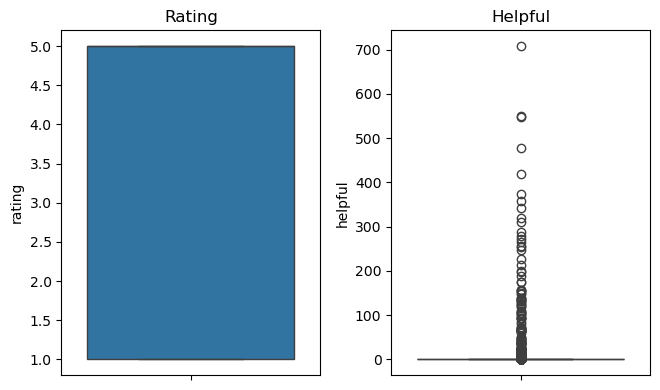

In [65]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
sns.boxplot(y=df['rating'])
plt.title("Rating")

plt.subplot(1,3,2)
sns.boxplot(y=df['helpful'])
plt.title("Helpful")

plt.tight_layout()
plt.show()


In [66]:
Q1 = df['helpful'].quantile(0.25)
Q3 = df['helpful'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [67]:
df = df[(df['helpful'] >= lower_bound) & (df['helpful'] <= upper_bound)]


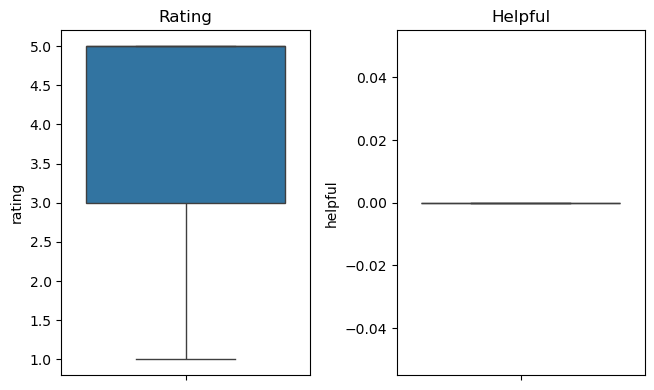

In [68]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
sns.boxplot(y=df['rating'])
plt.title("Rating")

plt.subplot(1,3,2)
sns.boxplot(y=df['helpful'])
plt.title("Helpful")

plt.tight_layout()
plt.show()

In [69]:
df['review_length'] = df['review_text'].str.len()

In [70]:
def sentiment_label(rating):
    if rating >= 4:
        return 'Positive'
    elif rating <= 2:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['rating'].apply(sentiment_label)


In [71]:
df['year'] = df['review_date'].dt.year
df['month'] = df['review_date'].dt.month

In [72]:
df.head()

,review_id,rating,review_text,review_date,helpful,review_length,sentiment,year,month
0,90749778-cd88-4c19-8b12-1fce7e7d82f8,4,kindly requesting to return change . we are fo...,2025-11-27 08:15:26,0,157,Positive,2025,11
1,aa848bb6-d242-4a7e-831e-4f21e2e60c6e,1,"Hiked prices, packing and platform charges",2025-11-27 08:08:31,0,42,Negative,2025,11
2,4f888388-9f28-44a4-8601-491a87035e53,5,good discount,2025-11-27 04:20:28,0,13,Positive,2025,11
3,490a16b3-aacf-4204-bdcb-ffdbf04add72,1,"Zomato in its initial days was too good, but c...",2025-11-27 03:34:38,0,146,Negative,2025,11
4,0090a503-13b8-4741-a7c0-42e811244563,5,good application,2025-11-27 02:50:58,0,16,Positive,2025,11


# Visuals

# Rating Distribution

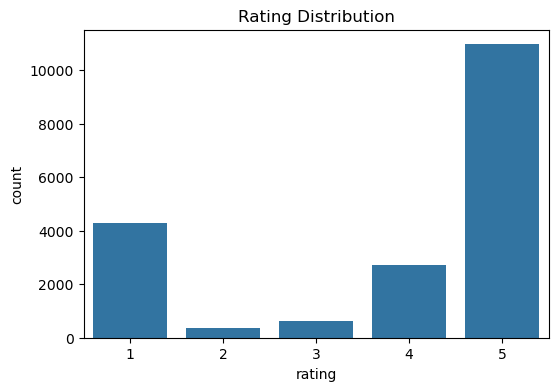

In [73]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution")
plt.show()


# Observation

1. Most of the rating are 5 which shows the customer satisfaction.
2. And very few ratings vary from 1-4 which shows most customers are satisfied with the zomoto services

# Sentiment Distribution

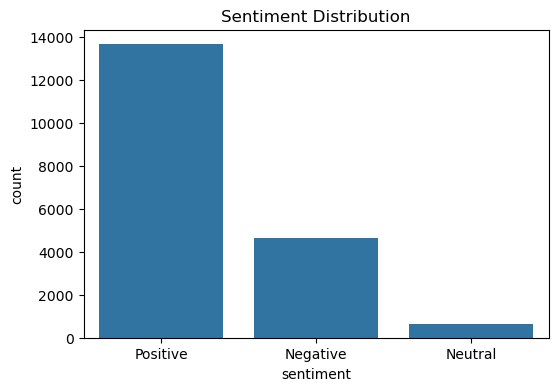

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

# Observation

1. Most of customers have positive feelings towards Zomoto which shows the companies services are good.
2. And very showed negative and netural reaction which shows for the company needs slight improvement in their service.

# Histogram

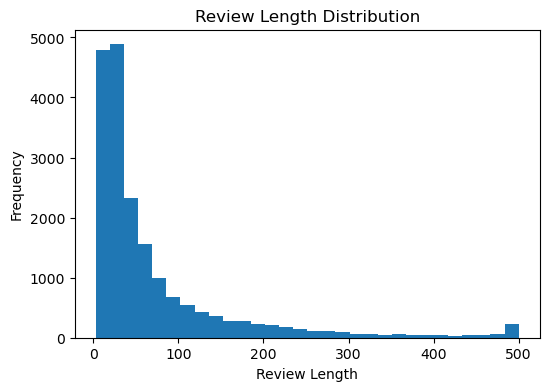

In [75]:
plt.figure(figsize=(6,4))
plt.hist(df['review_length'], bins=30)
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")
plt.show()

# Observation

1. Most of the reviwes length are short which falls under 0-200.
2. Customers are provided their reviews in the very short lengths.

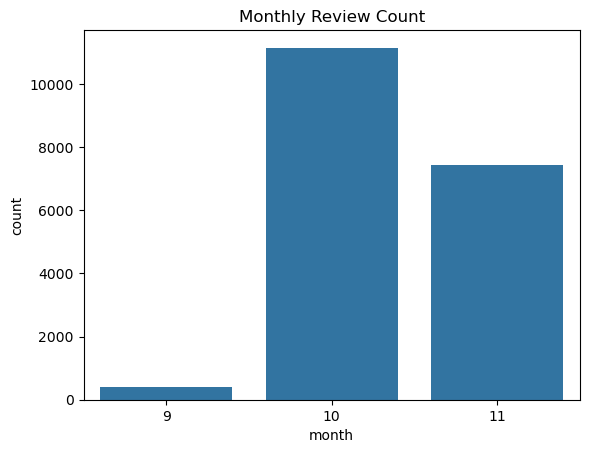

In [81]:
sns.countplot(x='month', data=df)
plt.title("Monthly Review Count")
plt.show()


# Observation

1. Most of the reviews are made in october month.

# Conclusion

1. Most customers give positive ratings (4 and 5), indicating overall satisfaction with the service.
2. Negative reviews are fewer, but they often contain longer and more detailed feedback, showing users explain issues more when dissatisfied.
3. Only a small number of reviews receive high helpful votes, meaning most users do not actively mark reviews as helpful.
4. Review activity is not evenly distributed over time, with certain months showing higher customer engagement.